# Database Quality Control Report

This notebook validates and visualizes various aspects of the PBI database to ensure data quality and provide insights into the database composition.

## Metrics Analyzed:
1. Number of entries per source database
2. Hosts in phage table vs hosts with available genomes
3. Phage quality (completeness) distribution
4. Host phylum distribution
5. Data source distribution
6. Phage lifestyle distribution
7. Host taxonomy analysis
8. Assembly quality levels

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pbi import quick_connect

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("📦 Packages imported successfully")

📦 Packages imported successfully


In [2]:
# Connect to the database
retriever = quick_connect()
print("✅ Connected to database")

# Get database statistics
stats = retriever.get_stats()
print("\n📊 Database Statistics:")
for category, values in stats.items():
    print(f"\n{category.upper()}:")
    for key, value in values.items():
        print(f"  {key}: {value:,}")

2026-02-05 13:24:41,509 - INFO - 📂 Checking FASTA index files:
2026-02-05 13:24:41,512 - INFO -    Phage index: True (52570.4 KB)
2026-02-05 13:24:41,513 - INFO -    Protein index: True (1432185.2 KB)
2026-02-05 13:24:41,516 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-02-05 13:24:41,524 - INFO -    Loaded mapping for 5362 hosts
2026-02-05 13:24:41,525 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-02-05 13:24:41,582 - INFO - 🔄 Starting background FASTA loading...
2026-02-05 13:24:41,584 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-02-05 13:24:41,584 - INFO - ✅ Initialization complete (FASTA loading in background)
2026-02-05 13:24:41,588 - INFO - ⏳ Waiting for FASTA loading to complete...


✅ Connected to database


2026-02-05 13:24:57,161 - INFO -    ✅ Phage FASTA loaded in 15.58s (873,717 sequences)
2026-02-05 13:24:57,163 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-02-05 13:29:48,889 - WARNING - ⚠️ Timeout after 300s - FASTA may still be loading
2026-02-05 13:31:15,450 - INFO -    ✅ Protein FASTA loaded in 378.29s (31,050,116 sequences)
2026-02-05 13:31:15,452 - INFO -    ℹ️  Using on-demand loading for 5,362 individual host files
2026-02-05 13:31:15,453 - INFO - 🎉 All FASTA files loaded in 393.87s
2026-02-05 13:31:23,410 - INFO - 🔍 Sample phage keys:
2026-02-05 13:31:23,411 - INFO -    - 'AE002163.1...'
2026-02-05 13:31:23,412 - INFO -    - 'AF009630.1...'
2026-02-05 13:31:23,414 - INFO -    - 'AF011378.1...'
2026-02-05 13:31:23,415 - INFO - 🔍 Sample protein keys:
2026-02-05 13:31:23,416 - INFO -    - 'AE002163.1 AAF39720.1...'
2026-02-05 13:31:23,417 - INFO -    - 'AE002163.1 AAF39721.1...'
2026-02-05 13:31:23,418 - INFO -    - 'AE002163.1 


📊 Database Statistics:

DATABASE:
  phages: 873,718
  proteins: 43,088,582
  hosts: 6,031
  phage_host_associations: 764,172

FASTA:
  phages: 873,717
  proteins: 31,050,116
  hosts: 5,362


## 1. Phage Entries per Source Database

2026-02-05 13:31:23,550 - INFO - 🔍 Querying phage metadata...
2026-02-05 13:31:24,640 - INFO - ✅ Retrieved metadata for 873,718 phages



📊 Phage Entries per Source Database:
Source Database  Count  Percentage
           GOV2 195699       22.40
            MGV 189680       21.71
          IMGVR 177361       20.30
            GPD 142809       16.34
         TemPhD  66823        7.65
           CHVD  44935        5.14
            GVD  31402        3.59
           IGVD  10021        1.15
         RefSeq   4637        0.53
            STV   4065        0.47
       PhagesDB   3754        0.43
        Genbank   2086        0.24
           DDBJ    290        0.03
           EMBL    156        0.02


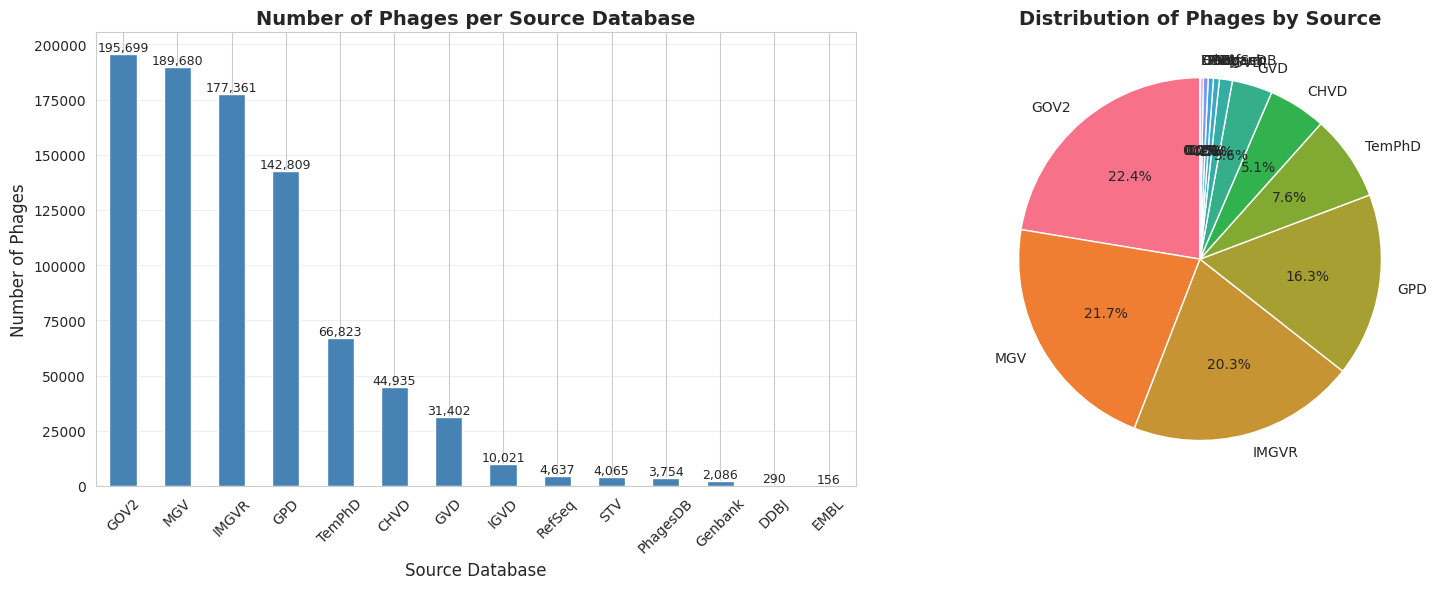

In [3]:
# Get phage metadata
phage_metadata = retriever.get_phage_metadata()

# Count entries per source
source_counts = phage_metadata['Source_DB'].value_counts().sort_values(ascending=False)

# Display table
print("\n📊 Phage Entries per Source Database:")
print("="*50)
source_df = pd.DataFrame({
    'Source Database': source_counts.index,
    'Count': source_counts.values,
    'Percentage': (source_counts.values / source_counts.sum() * 100).round(2)
})
print(source_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
source_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Number of Phages per Source Database', fontsize=14, fontweight='bold')
ax1.set_xlabel('Source Database', fontsize=12)
ax1.set_ylabel('Number of Phages', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(source_counts.values):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
colors = sns.color_palette('husl', len(source_counts))
ax2.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
ax2.set_title('Distribution of Phages by Source', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Hosts in Phage Table vs Available Host Genomes

2026-02-05 13:31:27,720 - INFO - 🔍 Querying host metadata...
2026-02-05 13:31:27,733 - INFO - ✅ Retrieved metadata for 6,031 hosts
2026-02-05 13:31:27,735 - INFO - 🔍 Querying phage-host metadata...
2026-02-05 13:31:33,238 - INFO - ✅ Retrieved metadata for 1,788,347 phage-host pairs



📊 Host Genome Coverage Analysis:
Unique hosts mentioned in phage table: 13,802
Hosts with available genomes: 6,031
Phage-host associations: 1,788,347
Unique phages in associations: 764,172
Unique hosts in associations: 5,362


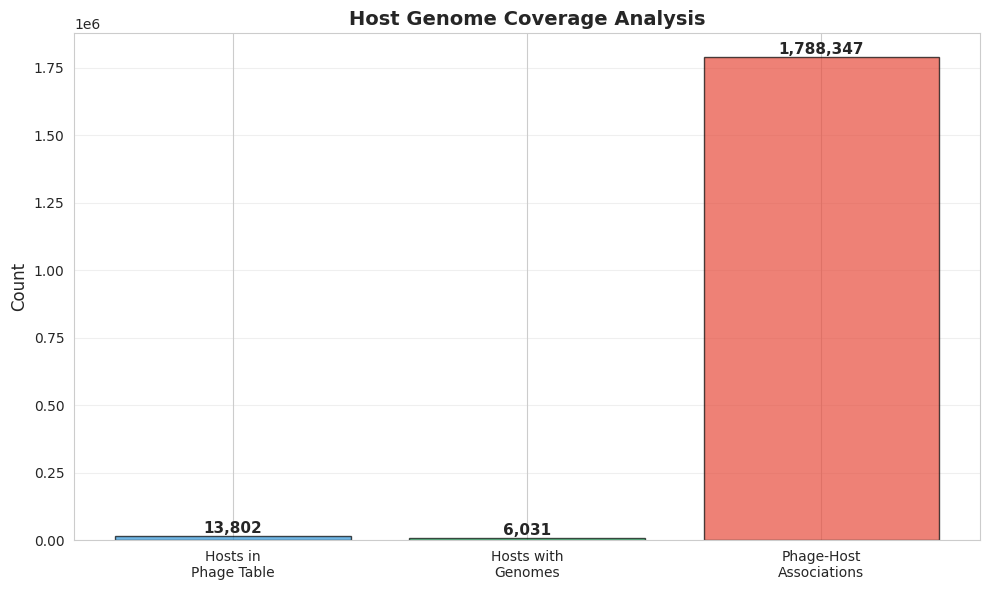

In [4]:
# Get unique hosts mentioned in phage table
hosts_in_phage_table = phage_metadata['Host'].dropna().unique()

# Get hosts with available genomes
try:
    host_metadata = retriever.get_host_metadata()
    hosts_with_genomes = host_metadata['Species_Name'].unique()
    
    # Get phage-host associations
    phage_host_pairs = retriever.get_phage_host_metadata()
    
    print("\n📊 Host Genome Coverage Analysis:")
    print("="*50)
    print(f"Unique hosts mentioned in phage table: {len(hosts_in_phage_table):,}")
    print(f"Hosts with available genomes: {len(hosts_with_genomes):,}")
    print(f"Phage-host associations: {len(phage_host_pairs):,}")
    print(f"Unique phages in associations: {phage_host_pairs['Phage_ID'].nunique():,}")
    print(f"Unique hosts in associations: {phage_host_pairs['Host_ID'].nunique():,}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = ['Hosts in\nPhage Table', 'Hosts with\nGenomes', 'Phage-Host\nAssociations']
    values = [len(hosts_in_phage_table), len(hosts_with_genomes), len(phage_host_pairs)]
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Host Genome Coverage Analysis', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️  Host genome data not available: {e}")
    print("   Run the host genome download workflow first.")

## 3. Phage Quality (Completeness) Distribution


📊 Phage Completeness Distribution:
Empty DataFrame
Columns: [Completeness, Count, Percentage]
Index: []


IndexError: index 0 is out of bounds for axis 0 with size 0

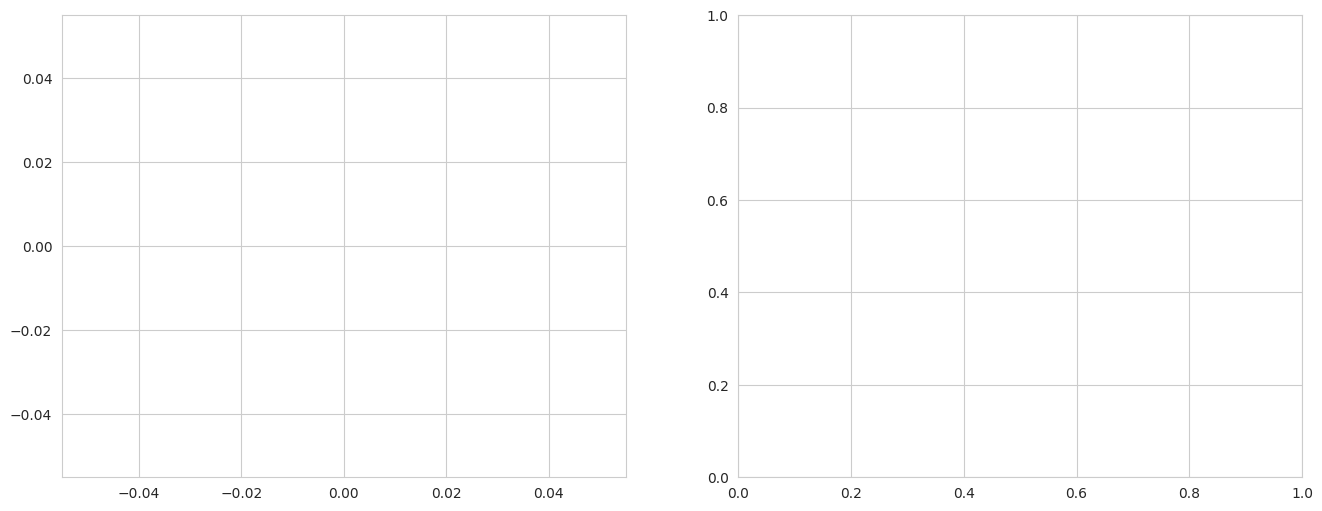

In [5]:
# Analyze completeness distribution
completeness_counts = phage_metadata['Completeness'].value_counts().sort_values(ascending=False)

print("\n📊 Phage Completeness Distribution:")
print("="*50)
completeness_df = pd.DataFrame({
    'Completeness': completeness_counts.index,
    'Count': completeness_counts.values,
    'Percentage': (completeness_counts.values / completeness_counts.sum() * 100).round(2)
})
print(completeness_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
completeness_counts.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Phage Completeness Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Phages', fontsize=12)
ax1.set_ylabel('Completeness Status', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(completeness_counts.values):
    ax1.text(v, i, f' {v:,}', va='center', fontsize=9)

# Pie chart
colors = sns.color_palette('Set2', len(completeness_counts))
ax2.pie(completeness_counts.values, labels=completeness_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Completeness Status Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Phage Lifestyle Distribution


📊 Phage Lifestyle Distribution:
Lifestyle  Count  Percentage
 virulent 553688       63.37
temperate 320030       36.63


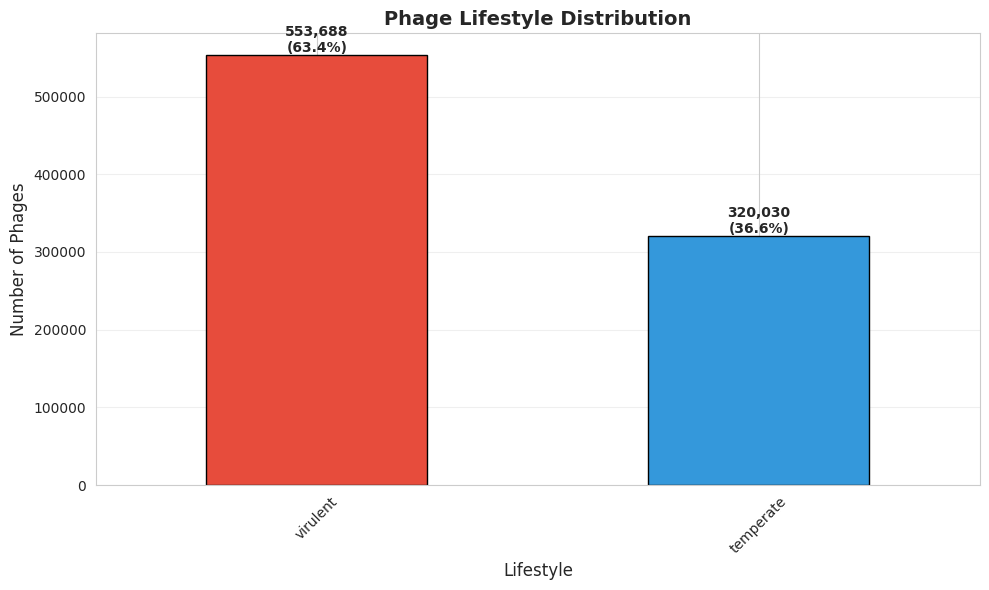

In [6]:
# Analyze lifestyle distribution
lifestyle_counts = phage_metadata['Lifestyle'].value_counts()

print("\n📊 Phage Lifestyle Distribution:")
print("="*50)
lifestyle_df = pd.DataFrame({
    'Lifestyle': lifestyle_counts.index,
    'Count': lifestyle_counts.values,
    'Percentage': (lifestyle_counts.values / lifestyle_counts.sum() * 100).round(2)
})
print(lifestyle_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#95a5a6']
lifestyle_counts.plot(kind='bar', ax=ax, color=colors[:len(lifestyle_counts)], edgecolor='black')
ax.set_title('Phage Lifestyle Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Lifestyle', fontsize=12)
ax.set_ylabel('Number of Phages', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(lifestyle_counts.values):
    ax.text(i, v, f'{v:,}\n({lifestyle_counts.values[i]/lifestyle_counts.sum()*100:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Phage Genome Length Distribution


📊 Phage Genome Length Statistics:
Mean length: 37,564 bp
Median length: 33,982 bp
Min length: 203 bp
Max length: 553,716 bp
Std deviation: 28,655 bp


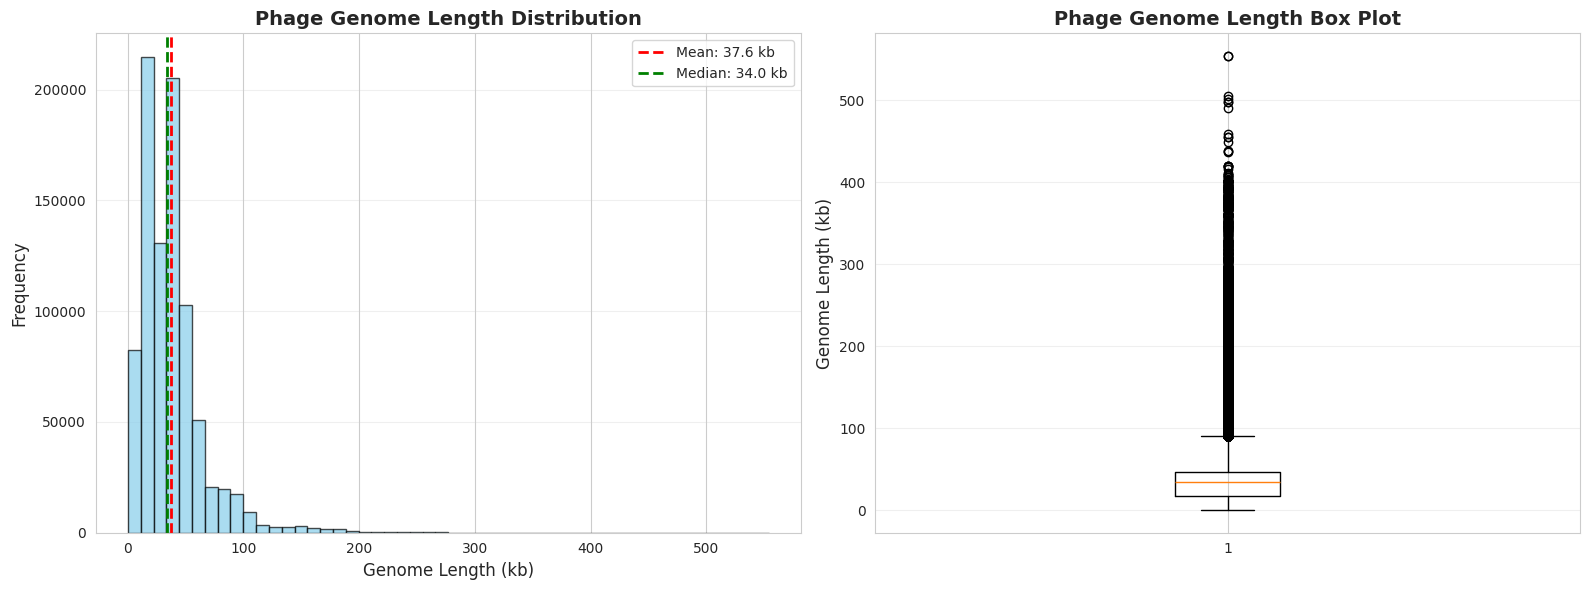

In [7]:
# Analyze genome length distribution
lengths = phage_metadata['Length'].dropna()

print("\n📊 Phage Genome Length Statistics:")
print("="*50)
print(f"Mean length: {lengths.mean():,.0f} bp")
print(f"Median length: {lengths.median():,.0f} bp")
print(f"Min length: {lengths.min():,.0f} bp")
print(f"Max length: {lengths.max():,.0f} bp")
print(f"Std deviation: {lengths.std():,.0f} bp")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(lengths/1000, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(lengths.mean()/1000, color='red', linestyle='--', linewidth=2, label=f'Mean: {lengths.mean()/1000:.1f} kb')
ax1.axvline(lengths.median()/1000, color='green', linestyle='--', linewidth=2, label=f'Median: {lengths.median()/1000:.1f} kb')
ax1.set_xlabel('Genome Length (kb)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage Genome Length Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2.boxplot(lengths/1000, vert=True)
ax2.set_ylabel('Genome Length (kb)', fontsize=12)
ax2.set_title('Phage Genome Length Box Plot', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Host Taxonomy Analysis


📊 Top 20 Host Species:
 1. Abditibacteriaceae                                     1
 2. Parasedimentitalea marina                              1
 3. Parolsenella                                           1
 4. Parendozoicomonas haliclonae                           1
 5. Paratractidigestivibacter faecalis                     1
 6. Paratractidigestivibacter                              1
 7. Parasynechococcus marenigrum                           1
 8. Parasutterella excrementihominis                       1
 9. Parasutterella                                         1
10. Parasporobacterium paucivorans                         1
11. Parasphingorhabdus                                     1
12. Pararobbsia silviterrae                                1
13. Parvibium lacunae                                      1
14. Pararobbsia alpina                                     1
15. Pararhodobacter sp.                                    1
16. Pararhodobacter marinus                                1


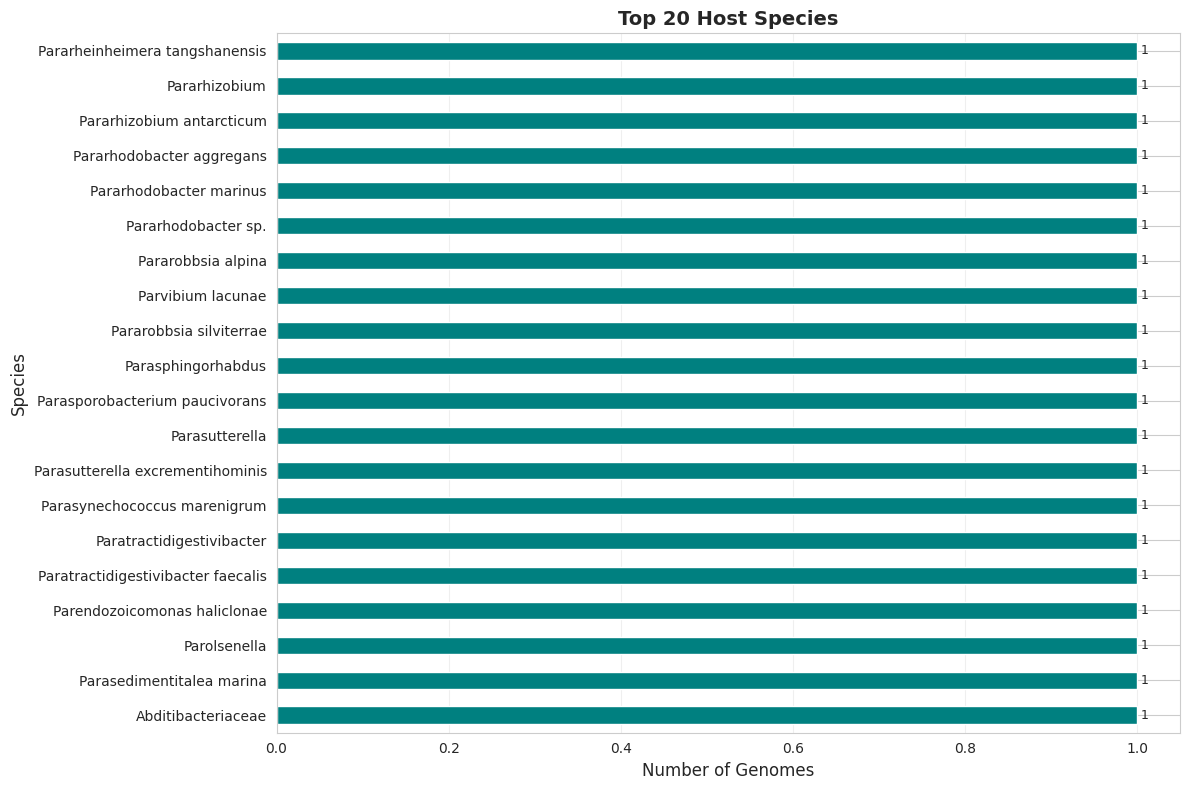

In [8]:
try:
    # Analyze host species distribution
    species_counts = host_metadata['Species_Name'].value_counts().head(20)
    
    print("\n📊 Top 20 Host Species:")
    print("="*50)
    for i, (species, count) in enumerate(species_counts.items(), 1):
        print(f"{i:2d}. {species:50s} {count:5d}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    species_counts.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 20 Host Species', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Genomes', fontsize=12)
    ax.set_ylabel('Species', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(species_counts.values):
        ax.text(v, i, f' {v}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️  Host taxonomy analysis not available: {e}")

## 7. Host Assembly Quality Distribution


📊 Host Assembly Level Distribution:
 Assembly Level  Count  Percentage
Complete Genome   2523       41.83
       Scaffold   1728       28.65
         Contig   1648       27.33
     Chromosome    132        2.19


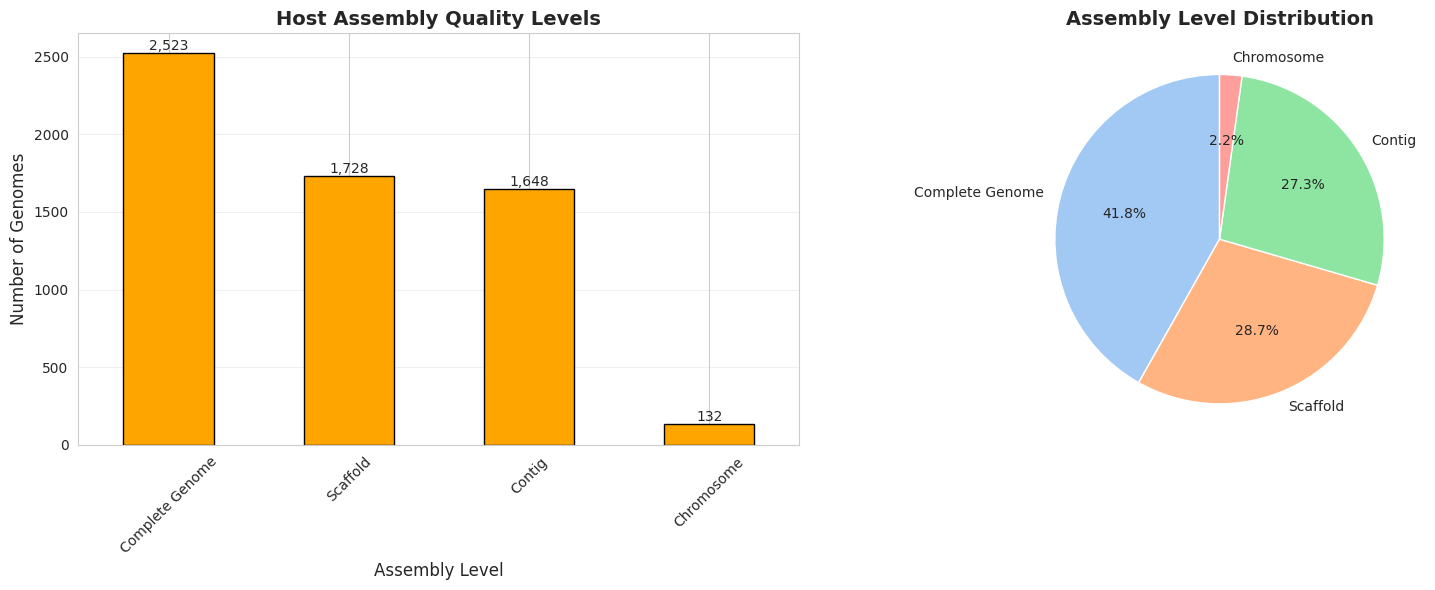

In [9]:
try:
    # Analyze assembly level distribution
    assembly_counts = host_metadata['Assembly_Level'].value_counts()
    
    print("\n📊 Host Assembly Level Distribution:")
    print("="*50)
    assembly_df = pd.DataFrame({
        'Assembly Level': assembly_counts.index,
        'Count': assembly_counts.values,
        'Percentage': (assembly_counts.values / assembly_counts.sum() * 100).round(2)
    })
    print(assembly_df.to_string(index=False))
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    assembly_counts.plot(kind='bar', ax=ax1, color='orange', edgecolor='black')
    ax1.set_title('Host Assembly Quality Levels', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Assembly Level', fontsize=12)
    ax1.set_ylabel('Number of Genomes', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(assembly_counts.values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
    
    # Pie chart
    colors = sns.color_palette('pastel', len(assembly_counts))
    ax2.pie(assembly_counts.values, labels=assembly_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    ax2.set_title('Assembly Level Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️  Assembly quality analysis not available: {e}")

## 8. GC Content Analysis


📊 Phage GC Content Statistics:
Mean GC%: 44.19%
Median GC%: 43.13%
Min GC%: 17.92%
Max GC%: 78.50%
Std deviation: 9.14%


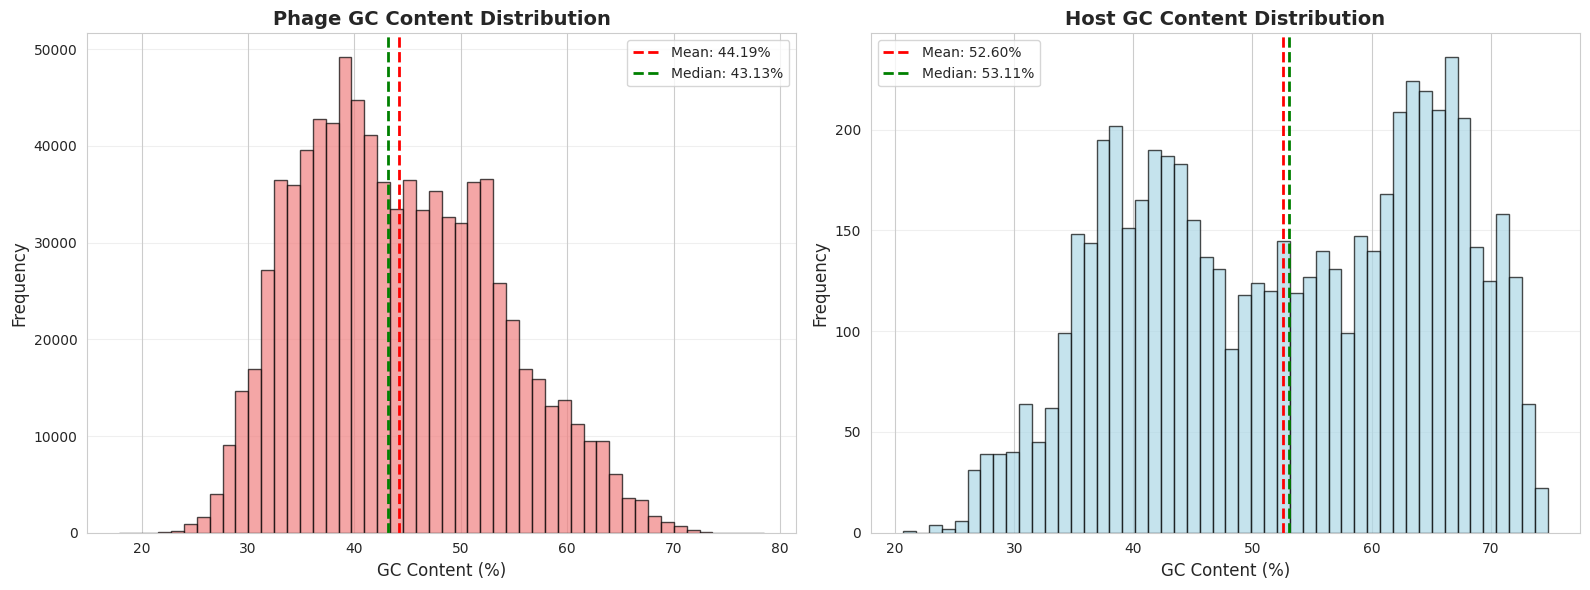

In [10]:
# Analyze GC content distribution
gc_content = phage_metadata['GC_content'].dropna()

print("\n📊 Phage GC Content Statistics:")
print("="*50)
print(f"Mean GC%: {gc_content.mean():.2f}%")
print(f"Median GC%: {gc_content.median():.2f}%")
print(f"Min GC%: {gc_content.min():.2f}%")
print(f"Max GC%: {gc_content.max():.2f}%")
print(f"Std deviation: {gc_content.std():.2f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for phages
ax1.hist(gc_content, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax1.axvline(gc_content.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {gc_content.mean():.2f}%')
ax1.axvline(gc_content.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {gc_content.median():.2f}%')
ax1.set_xlabel('GC Content (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage GC Content Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Host GC content if available
try:
    host_gc = host_metadata['GC_Content'].dropna()
    ax2.hist(host_gc, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    ax2.axvline(host_gc.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {host_gc.mean():.2f}%')
    ax2.axvline(host_gc.median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: {host_gc.median():.2f}%')
    ax2.set_xlabel('GC Content (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
except:
    ax2.text(0.5, 0.5, 'Host data not available', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Phage-Host Pair Analysis


📊 Phage-Host Pair Statistics:

Phage Lifestyle in Pairs:
  virulent: 1,094,319 (61.2%)
  temperate: 694,028 (38.8%)

Top 10 Phage Sources in Pairs:
  MGV: 418,156
  IMGVR: 379,599
  GOV2: 378,670
  GPD: 211,892
  TemPhD: 204,071
  CHVD: 85,340
  GVD: 66,921
  IGVD: 15,373
  RefSeq: 8,774
  STV: 7,813

Host Assembly Level in Pairs:
  Complete Genome: 1,646,760 (92.1%)
  Scaffold: 66,108 (3.7%)
  Contig: 62,347 (3.5%)
  Chromosome: 13,132 (0.7%)


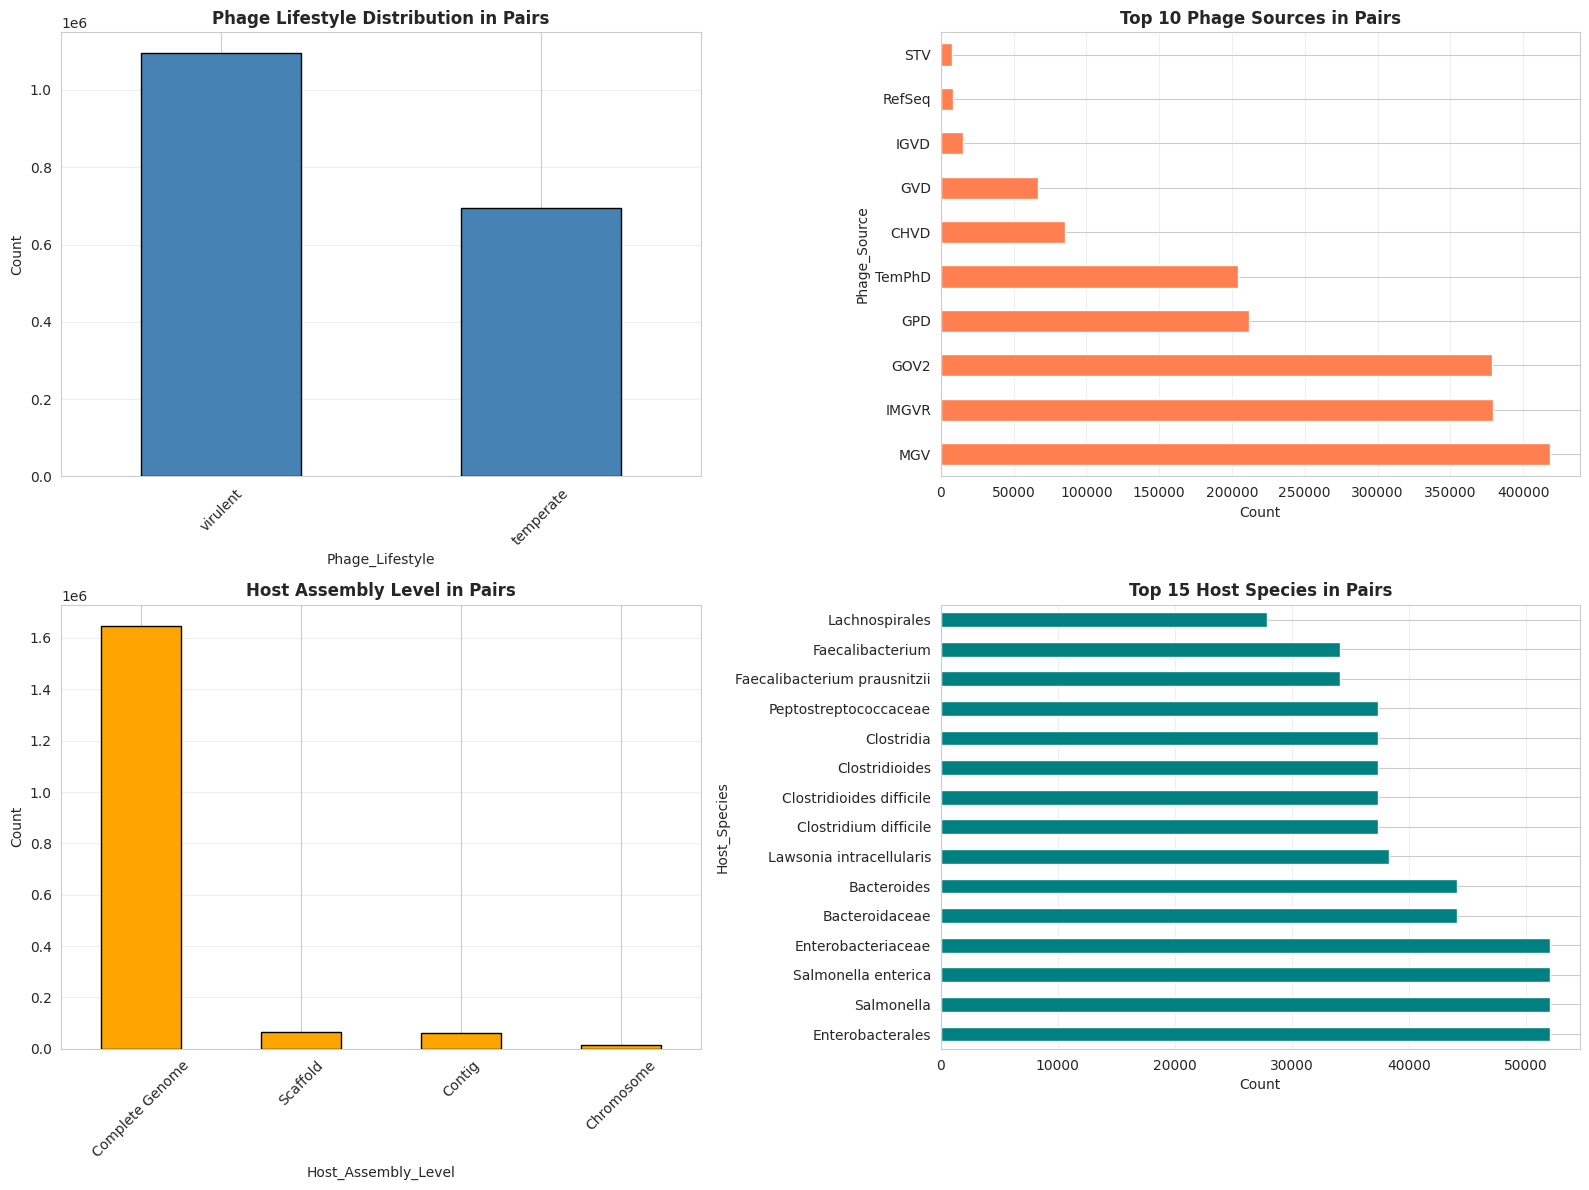

In [11]:
try:
    # Analyze phage-host metadata
    print("\n📊 Phage-Host Pair Statistics:")
    print("="*50)
    
    # Lifestyle distribution in pairs
    pair_lifestyle = phage_host_pairs['Phage_Lifestyle'].value_counts()
    print("\nPhage Lifestyle in Pairs:")
    for lifestyle, count in pair_lifestyle.items():
        print(f"  {lifestyle}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")
    
    # Source distribution in pairs
    pair_source = phage_host_pairs['Phage_Source'].value_counts().head(10)
    print("\nTop 10 Phage Sources in Pairs:")
    for source, count in pair_source.items():
        print(f"  {source}: {count:,}")
    
    # Assembly level distribution in pairs
    pair_assembly = phage_host_pairs['Host_Assembly_Level'].value_counts()
    print("\nHost Assembly Level in Pairs:")
    for level, count in pair_assembly.items():
        print(f"  {level}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Lifestyle in pairs
    pair_lifestyle.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
    axes[0,0].set_title('Phage Lifestyle Distribution in Pairs', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Count', fontsize=10)
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Source in pairs
    pair_source.plot(kind='barh', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Top 10 Phage Sources in Pairs', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Count', fontsize=10)
    axes[0,1].grid(axis='x', alpha=0.3)
    
    # Assembly level in pairs
    pair_assembly.plot(kind='bar', ax=axes[1,0], color='orange', edgecolor='black')
    axes[1,0].set_title('Host Assembly Level in Pairs', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Count', fontsize=10)
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # Top host species in pairs
    top_hosts = phage_host_pairs['Host_Species'].value_counts().head(15)
    top_hosts.plot(kind='barh', ax=axes[1,1], color='teal')
    axes[1,1].set_title('Top 15 Host Species in Pairs', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Count', fontsize=10)
    axes[1,1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️  Phage-host pair analysis not available: {e}")

## Summary

This notebook provides a comprehensive quality control analysis of the PBI database, including:

- ✅ Source database distribution
- ✅ Host genome coverage
- ✅ Phage quality metrics
- ✅ Lifestyle distribution
- ✅ Taxonomy analysis
- ✅ Assembly quality
- ✅ GC content statistics
- ✅ Phage-host pair characteristics

Use these visualizations to:
1. Validate data quality
2. Identify gaps in host genome coverage
3. Understand database composition
4. Plan improvements to data collection workflows

In [12]:
# Close database connection
retriever.close()
print("\n✅ Database connection closed")

2026-02-05 13:59:14,141 - INFO - 🔒 Database connection closed



✅ Database connection closed
